# FIFA & World Football Analysis (1930–2026)

This notebook explores historical football data including FIFA World Cup history, top scorers, FIFA rankings, and major football competitions.

Goals:
- Analyze World Cup trends
- Identify dominant countries
- Study top scorers
- Explore FIFA rankings
- Visualize football history

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
world_cup = pd.read_csv("archive/fifa_world_cup_history.csv")

top_scorers = pd.read_csv("archive/fifa_world_cup_top_scorers.csv")

rankings = pd.read_csv("archive/fifa_world_rankings_jan_2026.csv")

competitions = pd.read_csv("archive/football_major_competitions.csv")

In [3]:
print("World Cup Data:", world_cup.shape)
print("Top Scorers Data:", top_scorers.shape)
print("Rankings Data:", rankings.shape)
print("Competitions Data:", competitions.shape)

World Cup Data: (22, 10)
Top Scorers Data: (22, 5)
Rankings Data: (30, 7)
Competitions Data: (15, 9)


In [4]:
world_cup["Winner"].value_counts()

Winner
Brazil          5
Italy           4
West Germany    3
Argentina       3
Uruguay         2
France          2
England         1
Spain           1
Germany         1
Name: count, dtype: int64

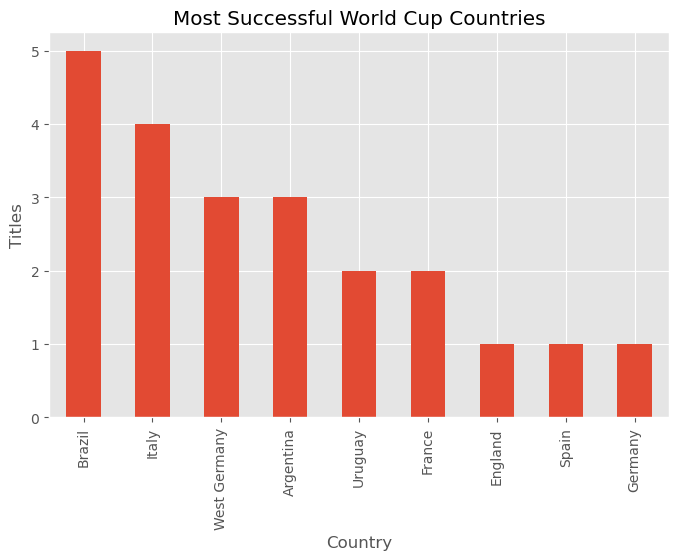

In [5]:
winners = world_cup["Winner"].value_counts()

plt.figure(figsize=(8,5))
winners.plot(kind="bar")

plt.title("Most Successful World Cup Countries")
plt.xlabel("Country")
plt.ylabel("Titles")

plt.show()

In [6]:
top_scorers = top_scorers.sort_values("Goals", ascending=False)

top_scorers.head(10)

,Year,Host,Player,Country,Goals
5,1958,Sweden,Just Fontaine,France,13
4,1954,Switzerland,Sándor Kocsis,Hungary,11
8,1970,Mexico,Gerd Müller,West Germany,10
7,1966,England,Eusébio,Portugal,9
3,1950,Brazil,Ademir,Brazil,8
0,1930,Uruguay,Guillermo Stábile,Argentina,8
21,2022,Qatar,Kylian Mbappé,France,8
16,2002,South Korea / Japan,Ronaldo,Brazil,8
9,1974,West Germany,Grzegorz Lato,Poland,7
2,1938,France,Leônidas,Brazil,7


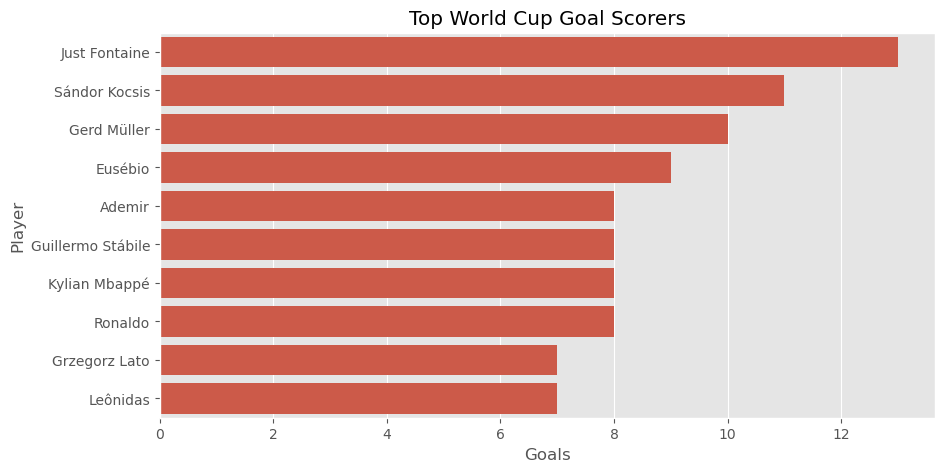

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Goals",
    y="Player",
    data=top_scorers.head(10)
)

plt.title("Top World Cup Goal Scorers")

plt.show()

In [8]:
rankings.head()

,Rank,Country,Points,Confederation,World_Cup_Titles,Best_WC_Finish,Continental_Titles
0,1,Spain,1877.18,UEFA,1,Champions (2010),12
1,2,Argentina,1873.33,CONMEBOL,3,Champions (2022),15
2,3,France,1870.00,UEFA,2,Champions (2018),3
3,4,England,1834.12,UEFA,1,Champions (1966),0
4,5,Brazil,1760.46,CONMEBOL,5,Champions (2002),9


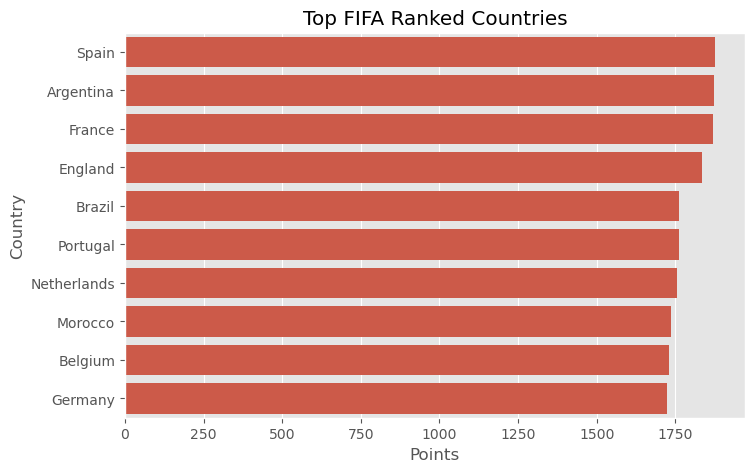

In [9]:
top_ranked = rankings.sort_values("Rank").head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Points",
    y="Country",
    data=top_ranked
)

plt.title("Top FIFA Ranked Countries")

plt.show()

In [10]:
competitions.head()

,Competition,Founded,Organizer,Frequency,Type,Region,Current_Champion,Most_Successful_Team,Most_Titles
0,FIFA World Cup,1930,FIFA,Every 4 years,International,Global,Argentina (2022),Brazil,5
1,UEFA Champions League,1955,UEFA,Annual,Club,Europe,Real Madrid (2024),Real Madrid,15
2,UEFA European Championship,1960,UEFA,Every 4 years,International,Europe,Spain (2024),Germany / Spain,3
3,Copa América,1916,CONMEBOL,Every 2–4 years,International,South America,Argentina (2024),Argentina / Uruguay,15
4,Africa Cup of Nations,1957,CAF,Every 2 years,International,Africa,Ivory Coast (2024),Egypt,7


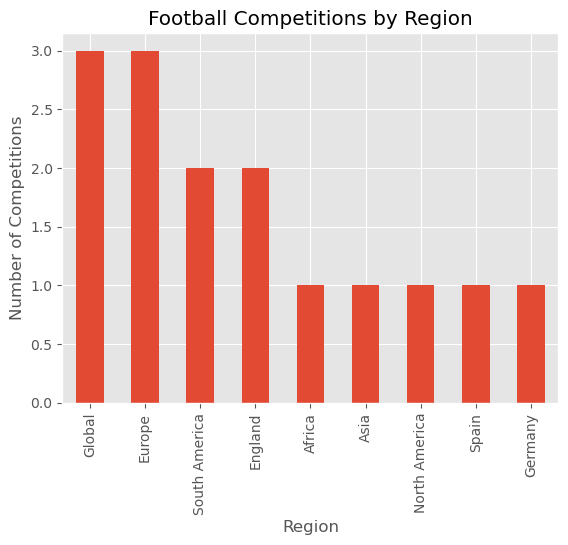

In [14]:
region_counts = competitions["Region"].value_counts()

plt.figure()

region_counts.plot(kind="bar")

plt.title("Football Competitions by Region")

plt.xlabel("Region")

plt.ylabel("Number of Competitions")

plt.show()

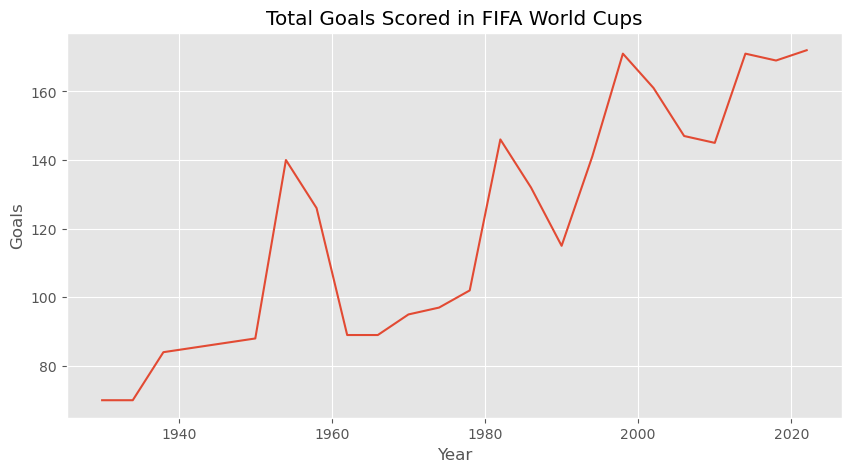

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    world_cup["Year"],
    world_cup["Total_Goals"]
)

plt.title("Total Goals Scored in FIFA World Cups")

plt.xlabel("Year")

plt.ylabel("Goals")

plt.show()

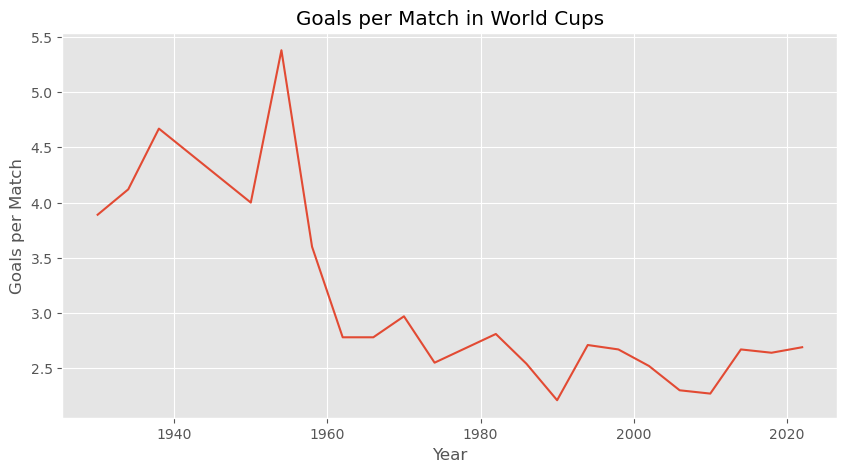

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    world_cup["Year"],
    world_cup["Goals_Per_Match"]
)

plt.title("Goals per Match in World Cups")

plt.xlabel("Year")

plt.ylabel("Goals per Match")

plt.show()

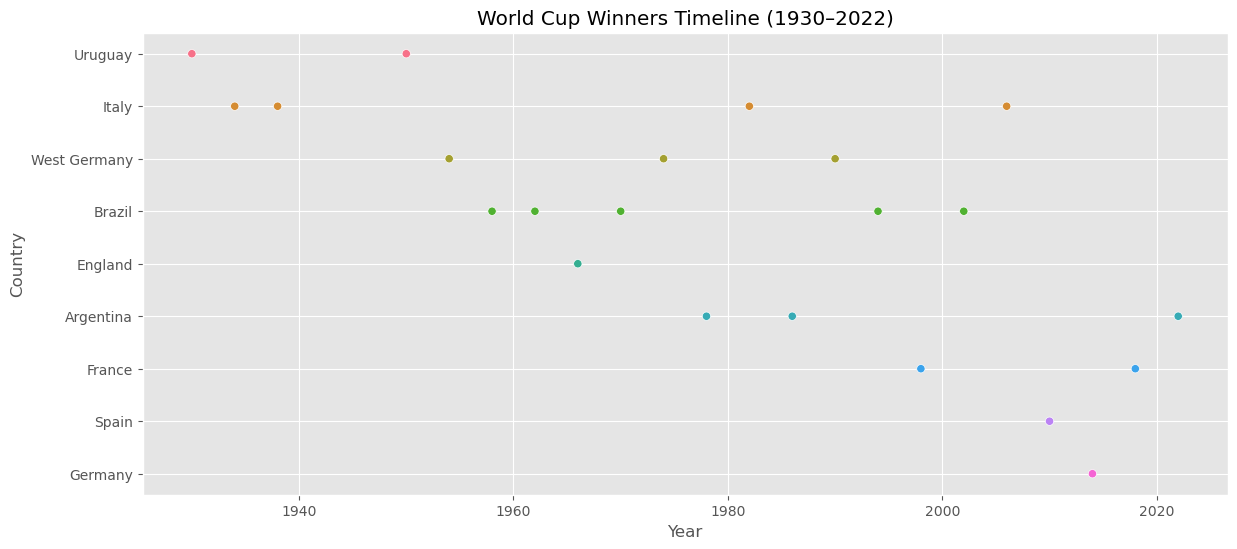

In [19]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    x="Year",
    y="Winner",
    data=world_cup,
    hue="Winner",
    legend=False
)

plt.title("World Cup Winners Timeline (1930–2022)")

plt.xlabel("Year")

plt.ylabel("Country")

plt.show()

In [23]:
wins = world_cup["Winner"].value_counts().reset_index()

wins.columns = ["Country", "Wins"]

wins

,Country,Wins
0,Brazil,5
1,Italy,4
2,West Germany,3
3,Argentina,3
4,Uruguay,2
5,France,2
6,England,1
7,Spain,1
8,Germany,1


C:\Users\thear\AppData\Local\Temp\ipykernel_3280\3018868997.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


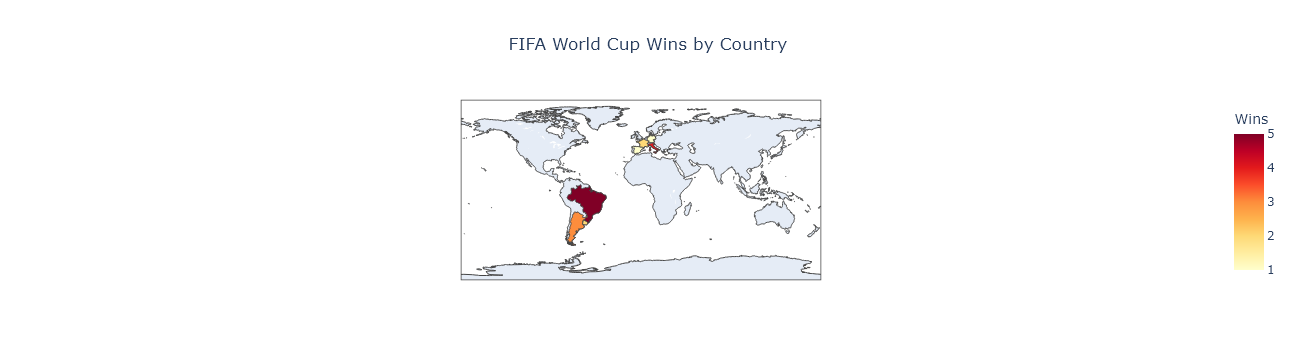

In [24]:
import plotly.express as px

fig = px.choropleth(
    wins,
    locations="Country",
    locationmode="country names",
    color="Wins",
    hover_name="Country",
    color_continuous_scale="YlOrRd",
    title="FIFA World Cup Wins by Country"
)

fig.update_layout(
    title_x=0.5
)

fig.show()